## 🧠💡 Intelligent Systems  for Smart Health 👨‍⚕👩‍⚕️

# Chest X-Ray Medical Diagnosis with Deep Learning
## CNNs - Part 2: Transfer Learning and Biases

In the previous session, we built our own CNN model to classify X-ray images, in our case for predicting medical conditions.
This was already a much more complicated task than the usual CNN tutorial material.

Since one patient could have multiple symptoms at the same time, the task was a so called *multi-label* prediction. This is usually more challenging than a *multi-class* prediction which also has several possible classes but where the algorithm only has to pick one class in the end. Here, this was not possible, so the output layer and loss functions had to be chosen accordingly.

In this session, we will start by simply repeating all data processing steps from the last session.
But then, we will not build a CNN model from scratch, but rather reuse an already trained (and much larger) CNN. This is called **transfer learning** because we transfer the parameters that were learned on a different task to our problem.

## The dataset

For this sesseion, we will be using the [ChestX-ray8 dataset](https://arxiv.org/abs/1705.02315) which contains 108,948 frontal-view X-ray images of about 30,000 unique patients. 
- Each image in the data set contains multiple text-mined labels identifying 14 different pathological conditions. 
- These in turn can be used by physicians to diagnose 8 different diseases. 
- We will use this data to develop a single model that will provide binary classification predictions for each of the 14 labeled pathologies. 
- In other words it will predict 'positive' or 'negative' for each of the pathologies.
 
The full dataset is available for free [here](https://nihcc.app.box.com/v/ChestXray-NIHCC).

**However, we will work with a smaller subset containing about 10% of the original data!!**

In [1]:
# Import necessary packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sb

# sometimes needed when running multiple pytorch kernels
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
# Just to check in the beginning --> later we also need the following:
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image, ImageReadMode

In [3]:
import warnings

# Suppress FutureWarning messages
warnings.simplefilter(action='ignore', category=FutureWarning)

---
## 1. Exploration
---

Read the data from `csv` files.

In [4]:
path_data = "../../../Data/ChestX_subset/"

metadata_df = pd.read_csv(os.path.join(path_data, "metadata.csv"))
metadata_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../../../Data/ChestX_subset/metadata.csv'

### Processing is identical to the last session!

So, no need to reproduce all inspection steps. We will simply run the same steps as last time in the following code cells.

In [5]:
print(
    f"The total patient ids are {metadata_df['patient_id'].count()}, \
from those the unique ids are {len(metadata_df['patient_id'].unique())}."
)

The total patient ids are 11212, from those the unique ids are 7181.


In [6]:
# Define actual labels (or classes)
non_class_columns = ['image',
                     'follow_up_no',
                     'patient_id',
                     'patient_age',
                     'gender',
                     'view_position']
classes = [c for c in metadata_df.columns if c not in non_class_columns]

# Get the total classes
print(f"There are {len(classes)} classes (or: labels)")
print(f"This includes: {classes}")

There are 15 classes (or: labels)
This includes: ['atelectasis', 'cardiomegaly', 'consolidation', 'edema', 'effusion', 'emphysema', 'fibrosis', 'hernia', 'infiltration', 'mass', 'no_finding', 'nodule', 'pleural_thickening', 'pneumonia', 'pneumothorax']


In [7]:
findings = metadata_df[list(classes)].sum()
findings.sort_values(ascending=False)  #.plot.barh()

no_finding            6070
infiltration          1982
effusion              1312
atelectasis           1156
nodule                 599
pneumothorax           570
mass                   569
consolidation          445
pleural_thickening     339
cardiomegaly           257
emphysema              254
edema                  240
fibrosis               164
pneumonia              122
hernia                  20
dtype: int64

Have a look at the counts for the labels in each class above. Does this look like a balanced dataset?

### 1.4 Data Visualization

Using the image names listed in the csv file, you can retrieve the image associated with each row of data in your dataframe. 

Run the cell below to visualize a random selection of images from the dataset.

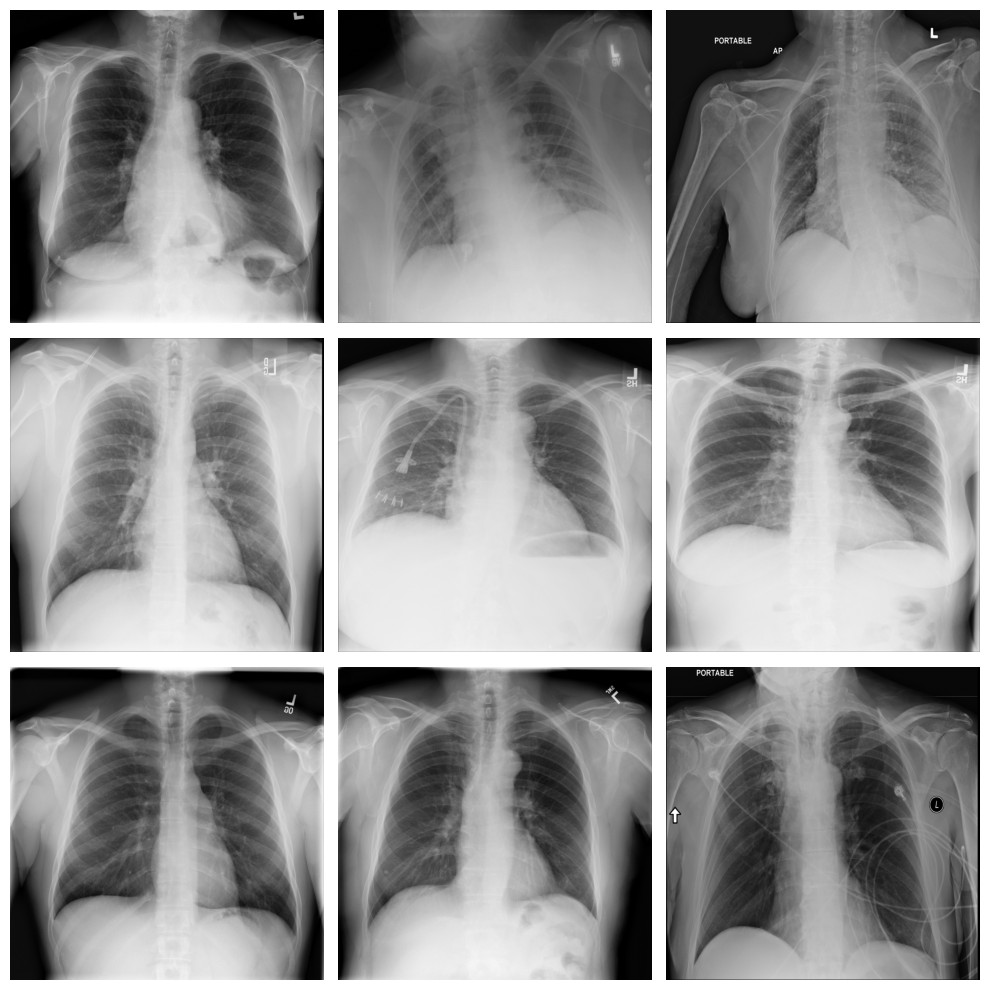

In [8]:
path_images = "../../../data/ChestX_subset/images/"

# Pick 9 random images
rng = np.random.default_rng(seed=0)  # set seed to make results reproducible
random_images = rng.choice(metadata_df.image, 9)

# Adjust the size of your images
plt.figure(figsize=(10,10))

# Iterate and plot random images
for i, filename in enumerate(random_images):
    filename = filename
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(path_images, filename))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
# Adjust subplot parameters to give specified padding
plt.tight_layout()    

### Split the data!?
One of the most fundamental concepts in machine learning is the distinction between *training* and *test* data.
In machine learning, our models "learn" from data. But, to be able to test later how well a model performs we should never use the same data as during training. Models can *overfit*, for instance (partly) learn by heart what to do with certain data points. The model would then only appear to perform well, giving drastically different predictions on new data.

For simpler machine learning scenarios it is often enough to reserve part of the data as a **test set**.

In deep learning, however, we commonly need two different types of test sets: One is called **validation set** and is used to optimize our model and the training, while a second **test set** is kept until the end of an optimization period for a final test of a model.

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(metadata_df, test_size=0.15,
                                     stratify=metadata_df['atelectasis'],
                                     random_state=0
                                    )
print(f"Training set size: {train_df.shape}")
print(f"Test set size: {test_df.shape}")

Training set size: (9530, 21)
Test set size: (1682, 21)


In [10]:
# second split

train_df, val_df = train_test_split(train_df, test_size=0.15,
                                    stratify=train_df['atelectasis'],
                                    random_state=0
                                    )
print(f"Training set size: {train_df.shape}")
print(f"Validation set size: {val_df.shape}")
print(f"Test set size: {test_df.shape}")

Training set size: (8100, 21)
Validation set size: (1430, 21)
Test set size: (1682, 21)


In [11]:
train_df.head()

,image,follow_up_no,patient_id,patient_age,gender,view_position,atelectasis,cardiomegaly,consolidation,edema,...,emphysema,fibrosis,hernia,infiltration,mass,no_finding,nodule,pleural_thickening,pneumonia,pneumothorax
10604,00013917_034.png,32,13917,55,M,AP,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1489,00001250_002.png,2,1250,66,F,PA,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5330,00000275_003.png,4,275,60,F,AP,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5229,00018055_007.png,8,18055,64,M,AP,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3806,00007245_000.png,0,7245,54,M,PA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [13]:
train_df.columns[6:]

Index(['atelectasis', 'cardiomegaly', 'consolidation', 'edema', 'effusion',
       'emphysema', 'fibrosis', 'hernia', 'infiltration', 'mass', 'no_finding',
       'nodule', 'pleural_thickening', 'pneumonia', 'pneumothorax'],
      dtype='object')

In [15]:
train_df.no_finding.value_counts()

no_finding
1    4411
0    3689
Name: count, dtype: int64

---
## 2. Image Preprocessing with Pytorch
---

Before training, you'll first modify your images to be better suited for training a convolutional neural network. For this task you'll use the Pytorch [transforms](https://pytorch.org/vision/stable/transforms.html) function to perform data preprocessing and data augmentation.

Run the next two cells to import this function and create an image generator for preprocessing.

### First: Build a Pytorch Dataset

In [16]:
from pytorch_utils import XRayDataset

In [18]:
training_data = XRayDataset(train_df, path_images, classes=train_df.columns[6:])
training_data.__getitem__(0)

(tensor([[[1, 1, 1,  ..., 1, 1, 1],
          [1, 2, 2,  ..., 2, 2, 1],
          [1, 2, 2,  ..., 2, 2, 1],
          ...,
          [2, 4, 6,  ..., 3, 3, 2],
          [2, 5, 6,  ..., 3, 3, 2],
          [0, 0, 1,  ..., 0, 0, 0]],
 
         [[1, 1, 1,  ..., 1, 1, 1],
          [1, 2, 2,  ..., 2, 2, 1],
          [1, 2, 2,  ..., 2, 2, 1],
          ...,
          [2, 4, 6,  ..., 3, 3, 2],
          [2, 5, 6,  ..., 3, 3, 2],
          [0, 0, 1,  ..., 0, 0, 0]],
 
         [[1, 1, 1,  ..., 1, 1, 1],
          [1, 2, 2,  ..., 2, 2, 1],
          [1, 2, 2,  ..., 2, 2, 1],
          ...,
          [2, 4, 6,  ..., 3, 3, 2],
          [2, 5, 6,  ..., 3, 3, 2],
          [0, 0, 1,  ..., 0, 0, 0]]], dtype=torch.uint8),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]))

What data does this return?

In [19]:
path_images = "../../../Data/ChestX_subset/images_low_resolution/"

training_data = XRayDataset(train_df, path_images, train_df.columns[6:])
(a, b) = training_data.__getitem__(0)

In [20]:
a.shape, b.shape

(torch.Size([3, 256, 256]), torch.Size([15]))

## Data generator with image transformation

In [42]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image, ImageReadMode
from torchvision.transforms import v2


transforms = v2.Compose([
    v2.ToImage(),                                    
    v2.Grayscale(num_output_channels=3),
    # Optional: Add data augmentation (not needed for valdation data)
    # v2.RandomRotation(15),
    # v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    v2.Resize(size=(224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),  # scales to values from 0.0 to 1.0
])

In [43]:
path_images = "../../../Data/ChestX_subset/images_low_resolution/"

training_data = XRayDataset(train_df, path_images, classes=train_df.columns[6:], transform=transforms)
train_dataloader = DataLoader(training_data, batch_size=2, shuffle=True)

In [44]:
x = next(iter(train_dataloader))

In [26]:
x[0].shape

torch.Size([2, 3, 224, 224])

In [27]:
x[0].min(), x[0].max()

(tensor(0.), tensor(0.9569))

---
---
# Transfer Learning: Use a pretrained CNN
---
---

We will use a pretrained CNN that is known to be very effective for image classification: `densenet` (see also ["Pytorch version of Densenet"](https://pytorch.org/hub/pytorch_vision_densenet/))


There are MANY more models available ([see documentation](https://docs.pytorch.org/vision/stable/models.html)). Common choices are **Densenet** or **Resnet**.

In [28]:
import torchvision
from torchvision import datasets, models, transforms
from torchvision.models.densenet import DenseNet121_Weights

model = torchvision.models.densenet121(weights=DenseNet121_Weights.DEFAULT)  

### Change the classifier part

The final part of those pretrained CNNs is the `classifier` (in this case a fully connected layer with 1024 inputs and 1000 outputs):

In [29]:
model.classifier

Linear(in_features=1024, out_features=1000, bias=True)

### Strategy: freeze pretrained model + replace/retrain classifier
(an alternative strategy is to only freeze lower-level layers of the pretrained model)

In [37]:
# Freeze the part of the model that should not be retrained
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier part
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features , 64),
    nn.ReLU(),
    nn.Linear(64 , 15),
    nn.Sigmoid(),
)

device = "cpu"  # or use GPU if you want/can
model = model.to(device)

## Visualize your model
Pytorch has no built-in model visualization. The output above (`print(model)`) only lists the explicitly included layers or modules but does not show the precise sizes or architecture.

One way to nicely visualize a pytorch model is via `onnx`. The onnx files can then be read using [the netron app](https://netron.app/).

In [40]:
#!pip install torchinfo

In [38]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
DenseNet                                 --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       (9,408)
│    └─BatchNorm2d: 2-2                  (128)
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
│    └─_DenseBlock: 2-5                  --
│    │    └─_DenseLayer: 3-1             (45,440)
│    │    └─_DenseLayer: 3-2             (49,600)
│    │    └─_DenseLayer: 3-3             (53,760)
│    │    └─_DenseLayer: 3-4             (57,920)
│    │    └─_DenseLayer: 3-5             (62,080)
│    │    └─_DenseLayer: 3-6             (66,240)
│    └─_Transition: 2-6                  --
│    │    └─BatchNorm2d: 3-7             (512)
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  (32,768)
│    │    └─AvgPool2d: 3-10              --
│    └─_DenseBlock: 2-7                  --
│    │    └─_DenseLayer: 3-11            (53,760)
│    │    └─

In [47]:
#!pip install onnx onnxscript

In [42]:
torch.onnx.export(model, x[0], 'xray_CNN.onnx', input_names=["features"], output_names=["predictions"])

---
## Code for model training (just an example)
---

In [35]:
import torch.nn as nn

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()

In [45]:
BATCH_SIZE = 16
path_images = "../../../Data/ChestX_subset/images_low_resolution/"

training_data = XRayDataset(train_df, path_images, classes=train_df.columns[6:], transform=transforms)
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# here: create validation_dataloader

In [31]:
from tqdm.notebook import tqdm

def train_one_epoch(model, epoch_index, tb_writer, training_dataloader, device="cpu"):
    running_loss = 0.
    avg_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(tqdm(training_dataloader)):
        
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs.to(device))

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        avg_loss += loss.item()
        if (i + 1) % training_dataloader.batch_size == 0:
            last_loss = running_loss / training_dataloader.batch_size  # loss per batch
            print(f"  batch {i +1} loss: {last_loss:.3f}")
            tb_x = epoch_index * len(training_dataloader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return avg_loss / (i + 1)

In [ ]:
# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/cnn_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 2

best_vloss = np.inf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training will happen on {device}.")

for epoch in range(EPOCHS):
    print(f"EPOCH {epoch_number + 1}")

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(model, epoch_number, writer, train_dataloader, device)

    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(validation_dataloader):
            if i > 10:
                break
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print(f"LOSS train {avg_loss:.3f} valid {avg_vloss:.3f}")

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars(
        'Training vs. Validation Loss',
        {'Training' : avg_loss, 'Validation' : avg_vloss},
        epoch_number + 1
    )
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"model_{timestamp}_{epoch_number}"
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

In [74]:
predictions_val = []
labels_val = []

for data in tqdm(validation_dataloader):
    with torch.no_grad(): 
        predictions_val.extend(model(data[0]))
    labels_val.extend(data[1])  

  0%|          | 0/90 [00:00<?, ?it/s]

In [75]:
labels_val = np.array(labels_val)
predictions_val = np.array([x.detach().numpy() for x in predictions_val])

In [76]:
predictions_val.shape

(1430, 15)

In [77]:
predictions_val[0, :]

array([0.09815431, 0.01978072, 0.06380947, 0.03271753, 0.15363982,
       0.02049731, 0.02107869, 0.00122911, 0.2038899 , 0.0569407 ,
       0.34415424, 0.05804215, 0.03216613, 0.00782046, 0.04686107],
      dtype=float32)

In [117]:
classes

['atelectasis',
 'cardiomegaly',
 'consolidation',
 'edema',
 'effusion',
 'emphysema',
 'fibrosis',
 'hernia',
 'infiltration',
 'mass',
 'no_finding',
 'nodule',
 'pleural_thickening',
 'pneumonia',
 'pneumothorax']

In [161]:
np.argsort(np.array(roc_auc))

array([ 7,  6, 12, 11,  5,  9, 13, 14,  0,  8, 10,  1,  4,  2,  3],
      dtype=int64)

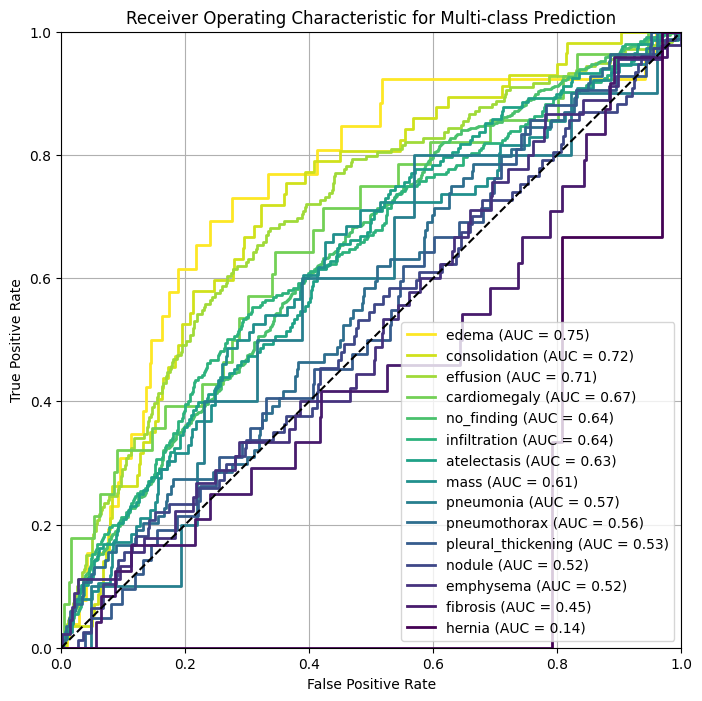

In [78]:
from model_evaluation import plot_roc_curves

plot_roc_curves(labels_val, predictions_val, classes=train_df.columns[6:])